In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.nn import GINConv, global_mean_pool
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix,
    ConfusionMatrixDisplay, precision_score,
    recall_score, f1_score
)
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import numpy as np
import random

# Reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.cuda.manual_seed_all(seed)

# === Load Dataset ===
def load_pytorch_dataset(file_path):
    with open(file_path, 'rb') as f:
        dataset = pickle.load(f)
    print(f"✅ Dataset successfully loaded from {file_path}")
    return dataset

pickle_file_path = r"C:\Users\nidhi\Downloads\Pickle files\Random Split\One-Hot\GPCR_A+B+C.pkl"
pytorch_dataset = load_pytorch_dataset(pickle_file_path)

# === Model ===
class SimpleGINModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate):
        super(SimpleGINModel, self).__init__()
        self.gin1 = GINConv(nn.Linear(input_dim, hidden_dim))
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.gin2 = GINConv(nn.Linear(hidden_dim, hidden_dim))
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.gin3 = GINConv(nn.Linear(hidden_dim, hidden_dim))
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.gin4 = GINConv(nn.Linear(hidden_dim, hidden_dim))
        self.bn4 = nn.BatchNorm1d(hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.bn1(self.gin1(x, edge_index)))
        x = F.relu(self.bn2(self.gin2(x, edge_index)))
        x = F.relu(self.bn3(self.gin3(x, edge_index)))
        x = F.relu(self.bn4(self.gin4(x, edge_index)))
        x = self.dropout(x)
        x = global_mean_pool(x, batch)
        return self.fc(x)

# === Training ===
def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct = 0, 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        data.y = data.y.long()
        out = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
        correct += (out.argmax(dim=1) == data.y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

# === Evaluation ===
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            data.y = data.y.long()
            out = model(data)
            loss = criterion(out, data.y)
            total_loss += loss.item() * data.num_graphs
            correct += (out.argmax(dim=1) == data.y).sum().item()
            probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
            all_labels.extend(data.y.cpu().numpy())
            all_preds.extend(out.argmax(dim=1).cpu().numpy())
            all_probs.extend(probs)
    return total_loss / len(loader.dataset), correct / len(loader.dataset), \
           np.array(all_labels), np.array(all_preds), np.array(all_probs)

# === Plot Training Metrics (Clean Style) ===
def plot_metrics(epochs, train_loss, train_acc, test_loss, test_acc, model_type):
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_loss, color="red")
    plt.plot(epochs, test_loss, color="orange")
    plt.plot(epochs, train_acc, color="green")
    plt.plot(epochs, test_acc, color="blue")
    plt.xticks([])
    plt.yticks([])
    plt.title(f"{model_type} Metrics", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{model_type}_metrics_plot.png", bbox_inches='tight')
    plt.close()
    print(f"🖼️ Metrics plot saved as {model_type}_metrics_plot.png")

# === Prepare Data ===
train_data, test_data = train_test_split(pytorch_dataset, test_size=0.2, random_state=seed)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# === Initialize Model ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleGINModel(20, 64, 2, 0.5).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

# === Training Loop ===
num_epochs = 350
train_losses, train_accs, test_losses, test_accs = [], [], [], []
history = []

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = train(model, train_loader, optimizer, criterion, device)
    te_loss, te_acc, y_true, y_pred, y_probs = evaluate(model, test_loader, criterion, device)

    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    test_losses.append(te_loss)
    test_accs.append(te_acc)
    history.append((y_true, y_pred, y_probs))

    print(f"Epoch {epoch:03d}: Train Loss={tr_loss:.4f}, Train Acc={tr_acc:.4f}, Test Loss={te_loss:.4f}, Test Acc={te_acc:.4f}")

# === Plot ===
plot_metrics(range(1, num_epochs + 1),
             train_losses, train_accs,
             test_losses, test_accs,
             "A+B+C_OneHot_64_NoWD"
)

# === Save to Excel ===
df_metrics = pd.DataFrame({
    "Epoch": list(range(1, num_epochs + 1)),
    "Train Accuracy": [round(acc * 100, 2) for acc in train_accs],
    "Train Loss": [round(loss, 2) for loss in train_losses],
    "Test Accuracy": [round(acc * 100, 2) for acc in test_accs],
    "Test Loss": [round(loss, 2) for loss in test_losses],
})

df_metrics.to_excel("A+B+C_OneHot_64_NoWD.xlsx", index=False)

✅ Loaded dataset from C:\Users\nidhi\Downloads\IICT\Pickle files\Random Split\One-Hot\GPCR_A+B+C.pkl
Epoch 001 | Train Loss: 0.6940, Train Acc: 0.5196 | Test Loss: 0.6552, Test Acc: 0.7005
Epoch 002 | Train Loss: 0.6715, Train Acc: 0.6547 | Test Loss: 0.6438, Test Acc: 0.7005
Epoch 003 | Train Loss: 0.6539, Train Acc: 0.6905 | Test Loss: 0.6370, Test Acc: 0.7465
Epoch 004 | Train Loss: 0.6353, Train Acc: 0.7240 | Test Loss: 0.6242, Test Acc: 0.7512
Epoch 005 | Train Loss: 0.6221, Train Acc: 0.7159 | Test Loss: 0.6108, Test Acc: 0.7512
Epoch 006 | Train Loss: 0.6096, Train Acc: 0.7182 | Test Loss: 0.5977, Test Acc: 0.7558
Epoch 007 | Train Loss: 0.5984, Train Acc: 0.7171 | Test Loss: 0.5867, Test Acc: 0.7558
Epoch 008 | Train Loss: 0.5867, Train Acc: 0.7194 | Test Loss: 0.5770, Test Acc: 0.7558
Epoch 009 | Train Loss: 0.5796, Train Acc: 0.7194 | Test Loss: 0.5685, Test Acc: 0.7558
Epoch 010 | Train Loss: 0.5709, Train Acc: 0.7217 | Test Loss: 0.5615, Test Acc: 0.7512
Epoch 011 | Train L

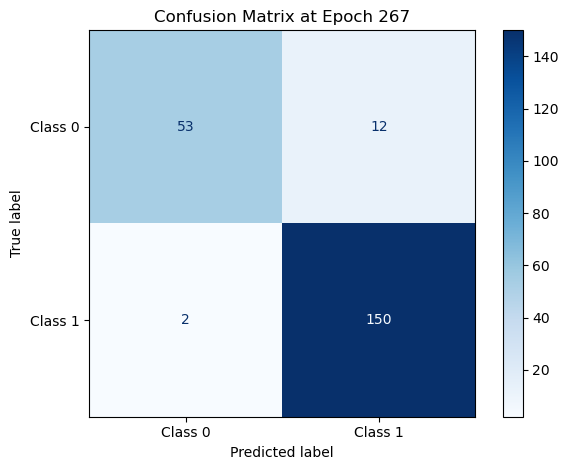

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.nn import GINConv, global_mean_pool
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import numpy as np
import random
import os

# === Reproducibility ===
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.cuda.manual_seed_all(seed)

# === Load Dataset ===
def load_pytorch_dataset(file_path):
    with open(file_path, 'rb') as f:
        dataset = pickle.load(f)
    print(f"✅ Loaded dataset from {file_path}")
    return dataset

pickle_file_path = r"C:\Users\nidhi\Downloads\IICT\Pickle files\Random Split\One-Hot\GPCR_A+B+C.pkl"
pytorch_dataset = load_pytorch_dataset(pickle_file_path)

# === Add unique ID to each graph for tracking ===
for idx, data in enumerate(pytorch_dataset):
    data.id = idx

# === GIN Model ===
class SimpleGINModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate):
        super(SimpleGINModel, self).__init__()
        self.gin1 = GINConv(nn.Linear(input_dim, hidden_dim))
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.gin2 = GINConv(nn.Linear(hidden_dim, hidden_dim))
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.gin3 = GINConv(nn.Linear(hidden_dim, hidden_dim))
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.gin4 = GINConv(nn.Linear(hidden_dim, hidden_dim))
        self.bn4 = nn.BatchNorm1d(hidden_dim)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.bn1(self.gin1(x, edge_index)))
        x = F.relu(self.bn2(self.gin2(x, edge_index)))
        x = F.relu(self.bn3(self.gin3(x, edge_index)))
        x = F.relu(self.bn4(self.gin4(x, edge_index)))
        x = self.dropout(x)
        x = global_mean_pool(x, batch)
        return self.fc(x)

# === Training Function ===
def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    for data in loader:
        data = data.to(device)
        data.y = data.y.long()
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
        correct += (out.argmax(1) == data.y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

# === Evaluation Function (includes accuracy!) ===
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    all_labels, all_preds, all_probs, all_ids = [], [], [], []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            data.y = data.y.long()
            out = model(data)
            loss = criterion(out, data.y)
            total_loss += loss.item() * data.num_graphs
            probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
            preds = out.argmax(1)
            correct += (preds == data.y).sum().item()
            all_labels.extend(data.y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs)
            all_ids.extend(data.id.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy, np.array(all_labels), np.array(all_preds), np.array(all_probs), np.array(all_ids)

# === Plotting function ===
def plot_metrics(epochs, train_loss, train_acc, test_loss, test_acc, tag):
    plt.figure(figsize=(10,6))
    plt.plot(epochs, train_loss, label='Train Loss', color='red')
    plt.plot(epochs, test_loss, label='Test Loss', color='orange')
    plt.plot(epochs, train_acc, label='Train Acc', color='green')
    plt.plot(epochs, test_acc, label='Test Acc', color='blue')
    plt.legend()
    plt.title(f"{tag} metrics")
    plt.tight_layout()
    fname = f"{tag}_metrics.png"
    plt.savefig(fname)
    plt.close()
    print(f"Saved metrics plot to {fname}")

# === Prepare Data ===
train_data, test_data = train_test_split(pytorch_dataset, test_size=0.2, random_state=seed)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# === Model Setup ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleGINModel(input_dim=20, hidden_dim=64, output_dim=2, dropout_rate=0.5).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# === Training Loop ===
num_epochs = 400
train_losses, train_accs = [], []
test_losses, test_accs = [], []

best_test_acc = -1
best_epoch_data = {}

for epoch in range(1, num_epochs+1):
    tr_loss, tr_acc = train(model, train_loader, optimizer, criterion, device)
    te_loss, te_acc, y_true, y_pred, y_probs, y_ids = evaluate(model, test_loader, criterion, device)

    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    test_losses.append(te_loss)
    test_accs.append(te_acc)

    print(f"Epoch {epoch:03d} | Train Loss: {tr_loss:.4f}, Train Acc: {tr_acc:.4f} | Test Loss: {te_loss:.4f}, Test Acc: {te_acc:.4f}")

    if te_acc > best_test_acc:
        best_test_acc = te_acc
        best_epoch_data = {
            'epoch': epoch,
            'y_true': y_true,
            'y_pred': y_pred,
            'y_ids': y_ids
        }

# === After Training: Best Epoch Results ===
best_epoch = best_epoch_data['epoch']
y_true = best_epoch_data['y_true']
y_pred = best_epoch_data['y_pred']
y_ids = best_epoch_data['y_ids']

conf_mat = confusion_matrix(y_true, y_pred)
print(f"\nConfusion Matrix at epoch {best_epoch} (Best Test Accuracy {best_test_acc:.4f}):\n{conf_mat}")

tp = y_ids[(y_true==1) & (y_pred==1)]
fp = y_ids[(y_true==0) & (y_pred==1)]
tn = y_ids[(y_true==0) & (y_pred==0)]
fn = y_ids[(y_true==1) & (y_pred==0)]

print(f"\nGraph Indices at epoch {best_epoch}:")
print(f"TP: {tp.tolist()}")
print(f"FP: {fp.tolist()}")
print(f"TN: {tn.tolist()}")
print(f"FN: {fn.tolist()}")

# === Save indices to file ===
with open(f"TP_FP_TN_FN_epoch_{best_epoch}.pkl", 'wb') as f:
    pickle.dump({'TP':tp.tolist(), 'FP':fp.tolist(), 'TN':tn.tolist(), 'FN':fn.tolist()}, f)
print(f"Saved TP/FP/TN/FN indices to TP_FP_TN_FN_epoch_{best_epoch}.pkl")

# === Plot confusion matrix ===
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=["Class 0","Class 1"])
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix at Epoch {best_epoch}")
plt.tight_layout()
plt.savefig(f"confusion_matrix_epoch_{best_epoch}.png")
plt.show()